In [150]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

folder = "simulations/scenario_1"
scenario_nr = folder[-1]

subfolders = [f.name for f in os.scandir(folder) if f.is_dir()]
subfolders = [f for f in subfolders if f not in  ['.ipynb_checkpoints']]

print("Number of available simulations:", len(subfolders))

Number of available simulations: 100


In [119]:
# Load stats for each method across all seeds
methods = ["mfvi", "ols", "gibbs"]
stats = {
    method: [
        pd.read_csv(f"{folder}/{seed}/{method}_stats.csv", index_col=0)
        for seed in subfolders
    ]
    for method in methods
}

display(stats["mfvi"][0])

# Row index of interest (as in the original code)
row = 1

r2 = {}
for method, dfs in stats.items():
    r2_train = [df.loc[row, "R2_train"] for df in dfs]
    r2_test = [df.loc[row, "R2_test"] for df in dfs]
    r2[method] = {
        "train": (np.mean(r2_train), np.std(r2_train)),
        "test": (np.mean(r2_test), np.std(r2_test)),
    }

r2["mfvi"]["test"]

,pip_tr,TP,TN,FP,FN,Precision,Recall,Accuracy,MCC,RMSE_beta_active,R2_beta_active,slope_beta_active,R2_train,R2_test
0,0.10,7,193,0,1,1.0,0.875,0.995025,0.933000,0.017169,0.997032,0.995017,0.670708,0.651438
1,0.50,7,193,0,1,1.0,0.875,0.995025,0.933000,0.017169,0.997032,0.995017,0.670708,0.651438
2,0.90,6,193,0,2,1.0,0.750,0.990050,0.861573,0.016477,0.997657,0.994918,0.669237,0.650816
3,0.95,5,193,0,3,1.0,0.625,0.985075,0.784496,0.014885,0.998406,0.994602,0.667652,0.650205
4,0.99,5,193,0,3,1.0,0.625,0.985075,0.784496,0.014885,0.998406,0.994602,0.667652,0.650205


(0.6494475675010711, 0.005571472431196274)

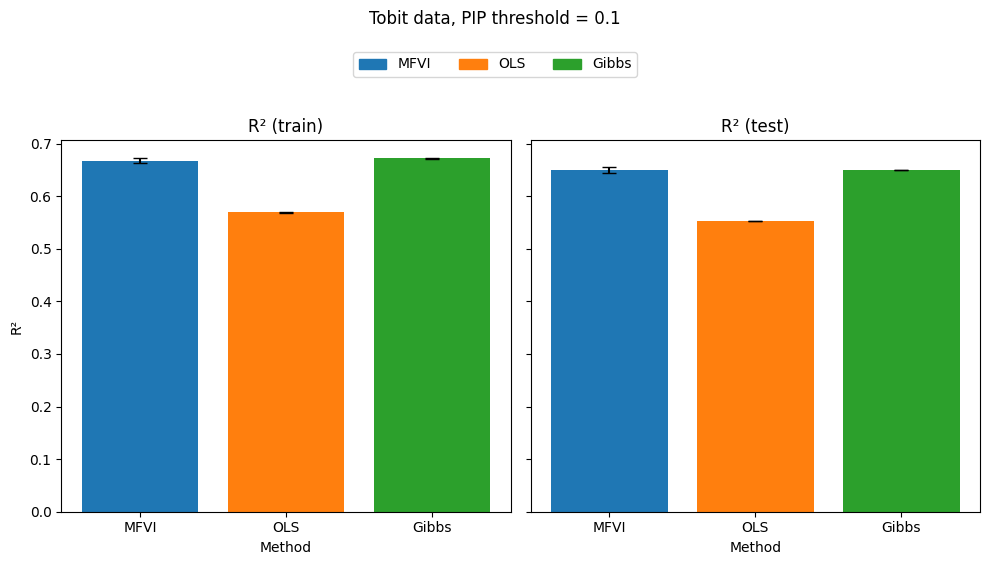

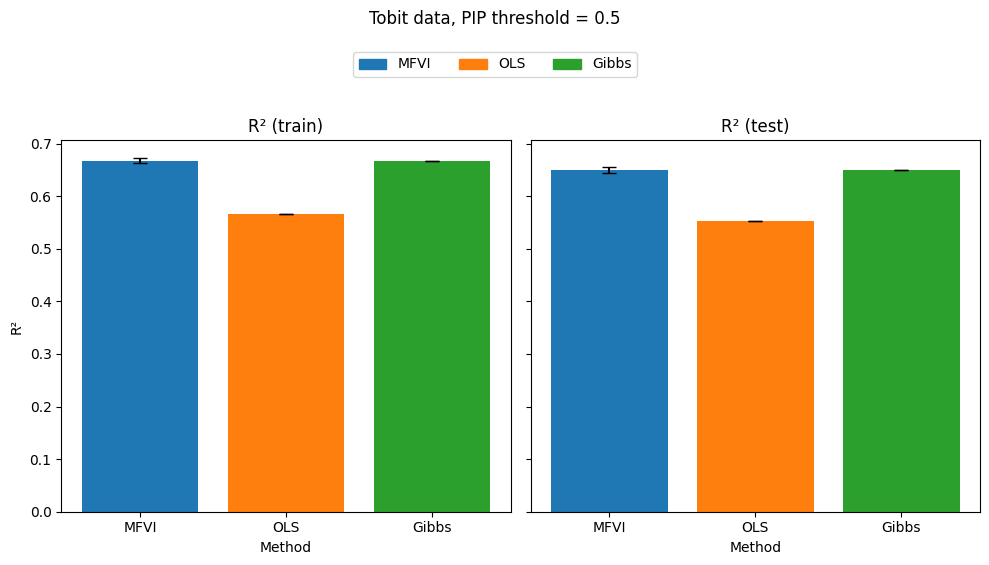

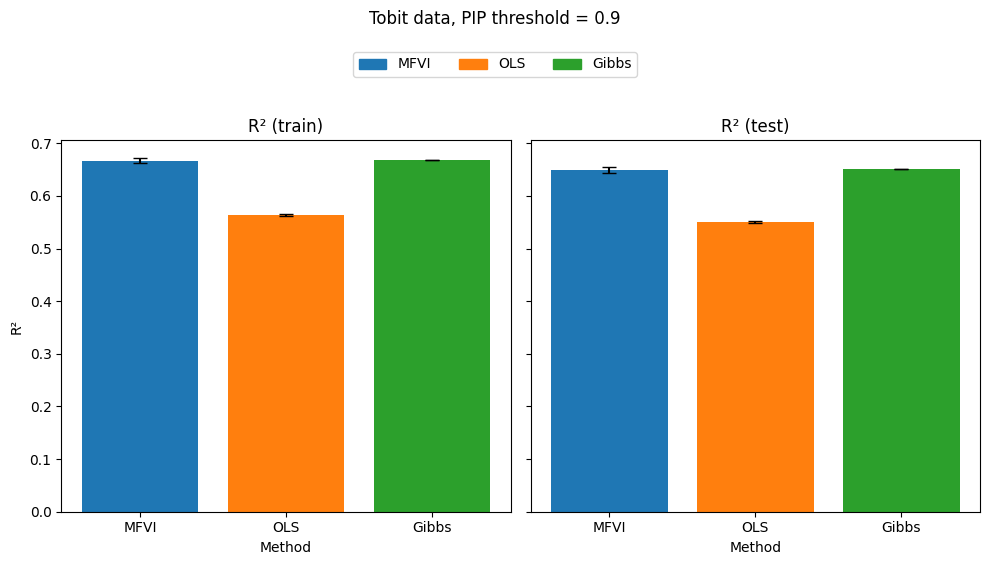

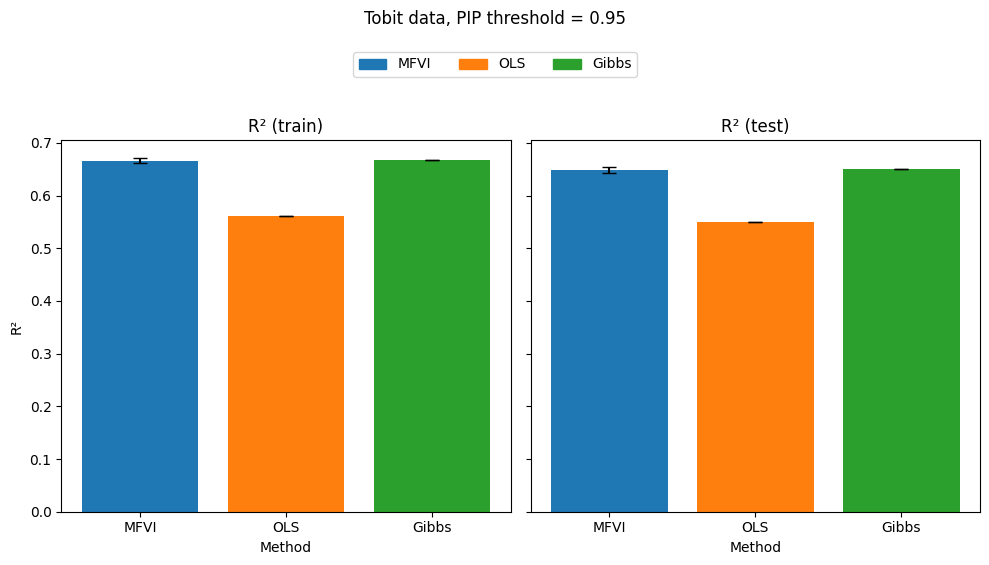

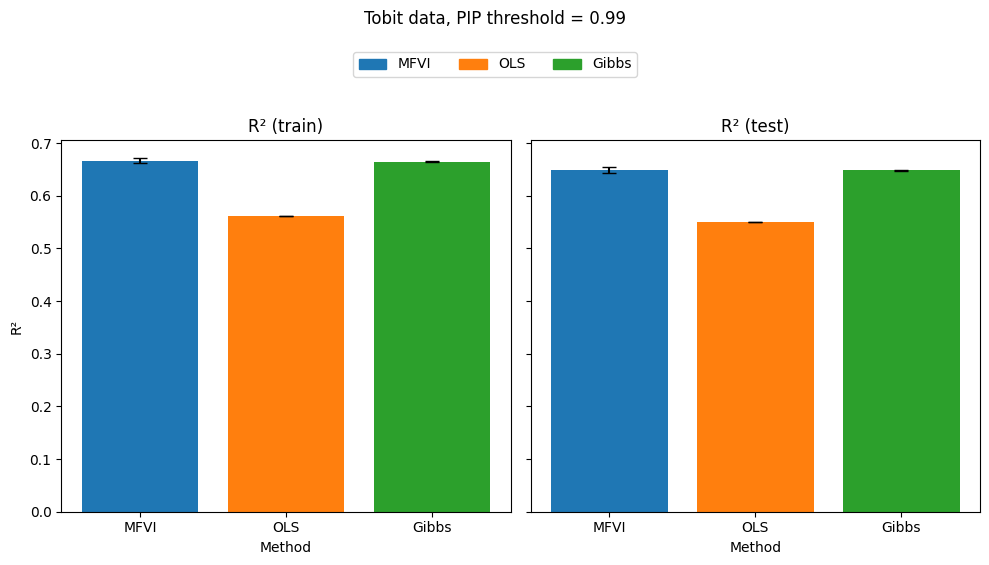

In [120]:
import matplotlib.pyplot as plt
import numpy as np

methods_order = ["mfvi", "ols", "gibbs"]
labels = {"mfvi": "MFVI", "ols": "OLS", "gibbs": "Gibbs"}
colors = {"mfvi": "tab:blue", "ols": "tab:orange", "gibbs": "tab:green"}

# All PIP thresholds available (assumed identical across seeds/methods)
pip_thresholds = stats["mfvi"][0]["pip_tr"].unique()

for pip_tr in pip_thresholds:
    # Compute mean/std R2 for this threshold, per method
    r2_thr = {}
    for method in methods_order:
        dfs = stats[method]
        r2_train = [df.loc[df["pip_tr"] == pip_tr, "R2_train"].iloc[0] for df in dfs]
        r2_test = [df.loc[df["pip_tr"] == pip_tr, "R2_test"].iloc[0] for df in dfs]
        r2_thr[method] = {
            "train": (np.mean(r2_train), np.std(r2_train)),
            "test": (np.mean(r2_test), np.std(r2_test)),
        }

    # Separate figure for this threshold
    fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

    for ax, split in zip(axes, ["train", "test"]):
        means = [r2_thr[m][split][0] for m in methods_order]
        stds = [r2_thr[m][split][1] for m in methods_order]
        bar_colors = [colors[m] for m in methods_order]

        ax.bar(
            [labels[m] for m in methods_order],
            means,
            yerr=stds,
            capsize=5,
            color=bar_colors,
        )

        ax.set_title(f"R² ({split})")
        ax.set_ylabel("R²" if split == "train" else "")
        ax.set_xlabel("Method")

    handles = [plt.Rectangle((0, 0), 1, 1, color=colors[m]) for m in methods_order]
    fig.legend(handles, [labels[m] for m in methods_order], loc="upper center",
               ncol=len(methods_order), bbox_to_anchor=(0.5, 1.05))

    fig.suptitle(f"Tobit data, PIP threshold = {pip_tr}", y=1.12)
    plt.tight_layout()
    plt.show()

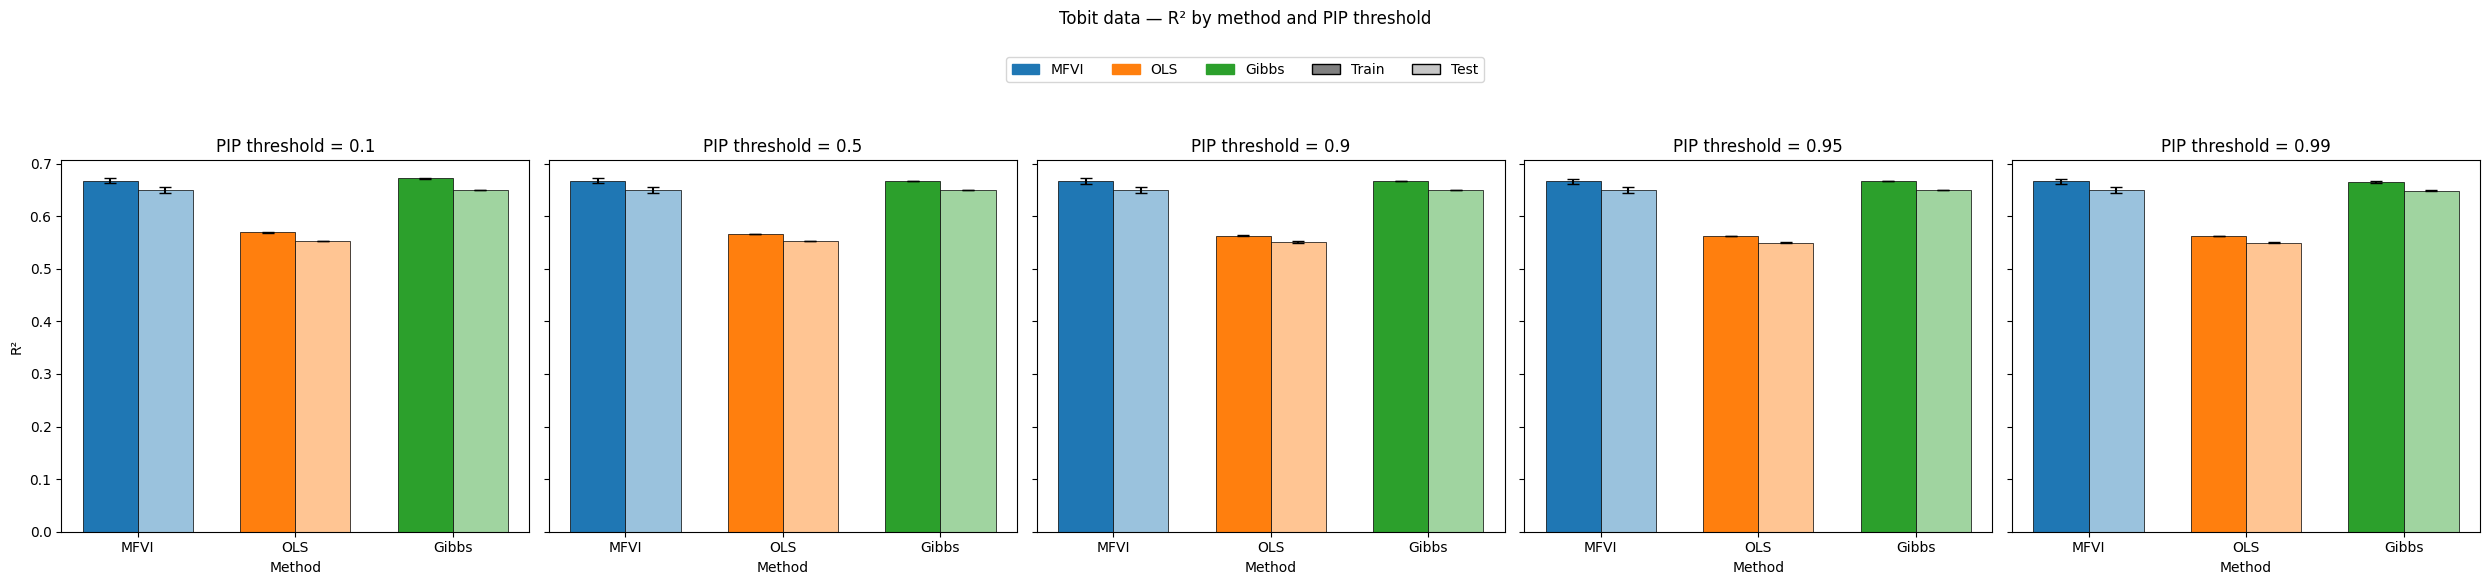

In [121]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import to_rgb

methods_order = ["mfvi", "ols", "gibbs"]
labels = {"mfvi": "MFVI", "ols": "OLS", "gibbs": "Gibbs"}
colors = {"mfvi": "tab:blue", "ols": "tab:orange", "gibbs": "tab:green"}

def lighten(color, amount=0.5):
    # Blend the color with white to produce a lighter shade
    r, g, b = to_rgb(color)
    return (r + (1 - r) * amount, g + (1 - g) * amount, b + (1 - b) * amount)

# All PIP thresholds available (assumed identical across seeds/methods)
pip_thresholds = stats["mfvi"][0]["pip_tr"].unique()

n_panels = len(pip_thresholds)
fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 5), sharey=True)
if n_panels == 1:
    axes = [axes]

bar_width = 0.35
x = np.arange(len(methods_order))

for ax, pip_tr in zip(axes, pip_thresholds):
    # Compute mean/std R2 for this threshold, per method
    means_train, stds_train = [], []
    means_test, stds_test = [], []
    for method in methods_order:
        dfs = stats[method]
        r2_train = [df.loc[df["pip_tr"] == pip_tr, "R2_train"].iloc[0] for df in dfs]
        r2_test = [df.loc[df["pip_tr"] == pip_tr, "R2_test"].iloc[0] for df in dfs]
        means_train.append(np.mean(r2_train))
        stds_train.append(np.std(r2_train))
        means_test.append(np.mean(r2_test))
        stds_test.append(np.std(r2_test))

    train_colors = [colors[m] for m in methods_order]
    test_colors = [lighten(colors[m], amount=0.55) for m in methods_order]

    ax.bar(x - bar_width / 2, means_train, bar_width, yerr=stds_train,
           capsize=4, color=train_colors, edgecolor="black", linewidth=0.5)
    ax.bar(x + bar_width / 2, means_test, bar_width, yerr=stds_test,
           capsize=4, color=test_colors, edgecolor="black", linewidth=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels([labels[m] for m in methods_order])
    ax.set_title(f"PIP threshold = {pip_tr}")
    ax.set_xlabel("Method")

axes[0].set_ylabel("R²")

# Single shared legend: method colors (train) + a train/test shade explanation
method_handles = [plt.Rectangle((0, 0), 1, 1, color=colors[m]) for m in methods_order]
shade_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor="gray", edgecolor="black"),
    plt.Rectangle((0, 0), 1, 1, facecolor=lighten("gray", 0.55), edgecolor="black"),
]
all_handles = method_handles + shade_handles
all_labels = [labels[m] for m in methods_order] + ["Train", "Test"]

fig.legend(all_handles, all_labels, loc="upper center", ncol=len(all_labels),
           bbox_to_anchor=(0.5, 1.08))
fig.suptitle("Tobit data — R² by method and PIP threshold", y=1.16)
plt.tight_layout()
plt.show()

In [122]:
import pandas as pd

pip_tr_target = 0.5
metrics = ["Precision", "Recall", "Accuracy", "MCC"]

summary_rows = []
for method in methods_order:
    dfs = stats[method]
    row = {"Method": labels[method]}
    for metric in metrics:
        values = [df.loc[df["pip_tr"] == pip_tr_target, metric].iloc[0] for df in dfs]
        row[f"{metric}_mean"] = np.mean(values)
        row[f"{metric}_std"] = np.std(values)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("Method")

# Reorder columns so mean/std pairs sit together per metric
ordered_cols = [f"{m}_{stat}" for m in metrics for stat in ("mean", "std")]
summary_df = summary_df[ordered_cols]

summary_df.round(3)

,Precision_mean,Precision_std,Recall_mean,Recall_std,Accuracy_mean,Accuracy_std,MCC_mean,MCC_std
Method,,,,,,,,
MFVI,1.0,0.0,0.676,0.099,0.987,0.004,0.815,0.061
OLS,1.0,0.0,0.625,0.000,0.985,0.000,0.784,0.000
Gibbs,1.0,0.0,0.625,0.000,0.985,0.000,0.784,0.000


In [123]:
methods = ["mfvi", "ols", "gibbs"]
betas = {
    method: [
        pd.read_csv(f"{folder}/{seed}/{method}_{seed}_beta.csv", index_col=0)
        for seed in subfolders
    ]
    for method in methods
}

display(betas["mfvi"][0].head())


,pip,true_sig,true_size,beta_mean,beta_std,beta_hdi_low,beta_hdi_high
var_idx,,,,,,,
0,1.000000e-10,False,0.0,-6.655322e-11,0.181659,-0.356045,0.356045
1,1.000000e-10,False,-0.0,-1.157547e-11,0.181659,-0.356045,0.356045
2,1.000000e-10,False,-0.0,-1.267518e-10,0.181659,-0.356045,0.356045
3,1.000000e-10,False,-0.0,-3.152319e-10,0.181659,-0.356045,0.356045
4,1.000000e-10,False,0.0,1.140954e-10,0.181659,-0.356045,0.356045


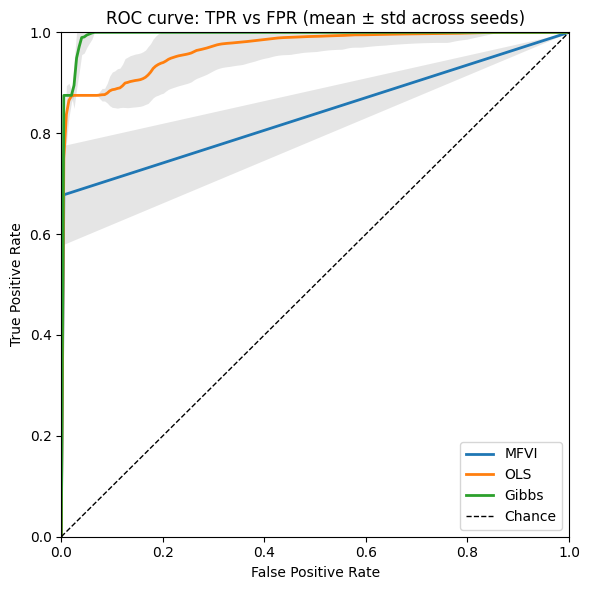

In [124]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

methods_order = ["mfvi", "ols", "gibbs"]
labels = {"mfvi": "MFVI", "ols": "OLS", "gibbs": "Gibbs"}
colors = {"mfvi": "tab:blue", "ols": "tab:orange", "gibbs": "tab:green"}

# Common FPR grid for interpolation across seeds
fpr_grid = np.linspace(0, 1, 200)

fig, ax = plt.subplots(figsize=(6, 6))

for method in methods_order:
    tpr_interp_list = []
    for df in betas[method]:
        y_true = df["true_sig"].astype(int).values
        y_score = df["pip"].values
        fpr, tpr, _ = roc_curve(y_true, y_score)
        # Interpolate this seed's ROC curve onto the common fpr grid
        tpr_interp = np.interp(fpr_grid, fpr, tpr)
        tpr_interp[0] = 0.0  # anchor curve at origin
        tpr_interp_list.append(tpr_interp)

    tpr_mean = np.mean(tpr_interp_list, axis=0)
    tpr_std = np.std(tpr_interp_list, axis=0)

    # Shaded +- std band in gray
    ax.fill_between(
        fpr_grid,
        np.clip(tpr_mean - tpr_std, 0, 1),
        np.clip(tpr_mean + tpr_std, 0, 1),
        color="gray",
        alpha=0.2,
        linewidth=0,
    )
    # Mean ROC curve in the method's established color
    ax.plot(fpr_grid, tpr_mean, color=colors[method], label=labels[method], linewidth=2)

ax.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1, label="Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curve: TPR vs FPR (mean ± std across seeds)")
ax.legend(loc="lower right")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

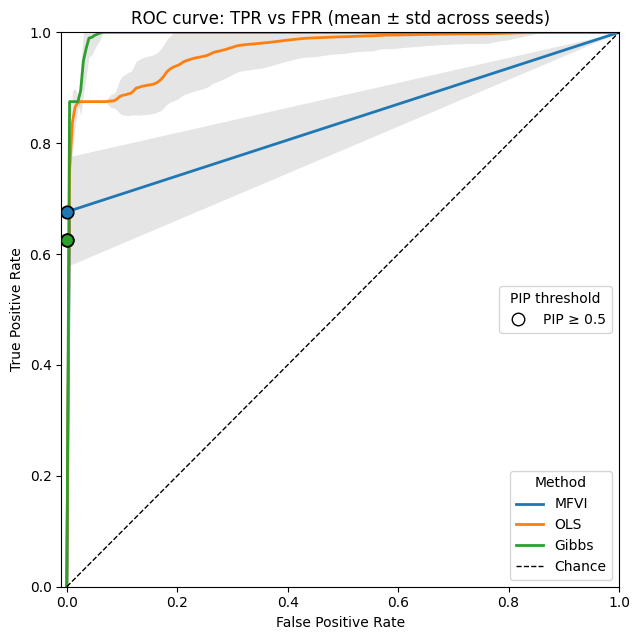

In [125]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.metrics import roc_curve

methods_order = ["mfvi", "ols", "gibbs"]
labels = {"mfvi": "MFVI", "ols": "OLS", "gibbs": "Gibbs"}
colors = {"mfvi": "tab:blue", "ols": "tab:orange", "gibbs": "tab:green"}

# PIP thresholds to highlight, with one marker shape per threshold
pip_thresholds = [0.5]
threshold_markers = {0.5: "o"}


def fpr_tpr_at_threshold(y_true, y_score, thr):
    """Return (FPR, TPR) for the decision rule pip >= thr."""
    n_pos = (y_true == 1).sum()
    n_neg = (y_true == 0).sum()
    if n_pos == 0 or n_neg == 0:
        return np.nan, np.nan  # undefined for this seed
    pred = y_score >= thr
    tp = np.sum(pred & (y_true == 1))
    fp = np.sum(pred & (y_true == 0))
    return fp / n_neg, tp / n_pos


# Common FPR grid for interpolation across seeds
fpr_grid = np.linspace(0, 1, 200)

fig, ax = plt.subplots(figsize=(6.5, 6.5))

for method in methods_order:
    tpr_interp_list = []
    thr_points = {t: [] for t in pip_thresholds}  # per-seed (fpr, tpr) at each threshold

    for df in betas[method]:
        y_true = df["true_sig"].astype(int).values
        y_score = df["pip"].values

        fpr, tpr, _ = roc_curve(y_true, y_score)
        # Interpolate this seed's ROC curve onto the common fpr grid
        tpr_interp = np.interp(fpr_grid, fpr, tpr)
        tpr_interp[0] = 0.0  # anchor curve at origin
        tpr_interp_list.append(tpr_interp)

        # Operating points at the selected PIP thresholds
        for t in pip_thresholds:
            thr_points[t].append(fpr_tpr_at_threshold(y_true, y_score, t))

    tpr_mean = np.mean(tpr_interp_list, axis=0)
    tpr_std = np.std(tpr_interp_list, axis=0)

    # Shaded +- std band in gray
    ax.fill_between(
        fpr_grid,
        np.clip(tpr_mean - tpr_std, 0, 1),
        np.clip(tpr_mean + tpr_std, 0, 1),
        color="gray",
        alpha=0.2,
        linewidth=0,
    )
    # Mean ROC curve in the method's established color
    ax.plot(fpr_grid, tpr_mean, color=colors[method], label=labels[method], linewidth=2)

    # Mean operating point (averaged over seeds) at each PIP threshold
    for t in pip_thresholds:
        pts = np.array(thr_points[t])  # shape (n_seeds, 2)
        fpr_t, tpr_t = np.nanmean(pts, axis=0)
        ax.plot(
            fpr_t, tpr_t,
            marker=threshold_markers[t],
            markersize=9,
            markerfacecolor=colors[method],
            markeredgecolor="black",
            markeredgewidth=1.2,
            linestyle="none",
            zorder=5,
        )

ax.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1, label="Chance")

# Two legends: methods (lines) and PIP thresholds (marker shapes)
leg_methods = ax.legend(loc="lower right", title="Method")
ax.add_artist(leg_methods)

thr_handles = [
    Line2D([0], [0], marker=threshold_markers[t], color="none",
           markerfacecolor="white", markeredgecolor="black",
           markersize=9, label=f"PIP ≥ {t}")
    for t in pip_thresholds
]
ax.legend(handles=thr_handles, loc="center right", title="PIP threshold")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curve: TPR vs FPR (mean ± std across seeds)")
ax.set_xlim(-0.01, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

In [126]:
methods_order = ["mfvi", "ols", "gibbs"]
labels = {"mfvi": "MFVI", "ols": "OLS", "gibbs": "Gibbs"}

time = {
    method: [
        pd.read_csv(f"{folder}/{seed}/{method}_{seed}_time.csv", index_col=0)
        for seed in subfolders
    ]
    for method in methods
}



# Columns to summarize (adjust if some methods lack certain columns, e.g. n_iters/coverged)
time_metrics = ["total_fit_time", "n_iters"]

summary_rows = []
for method in methods_order:
    dfs = time[method]
    row = {"Method": labels[method]}
    for metric in time_metrics:
        if metric not in dfs[0].columns:
            continue
        values = [df[metric].iloc[0] for df in dfs]
        row[f"{metric}_mean"] = np.mean(values)
        row[f"{metric}_std"] = np.std(values)
    summary_rows.append(row)

time_summary_df = pd.DataFrame(summary_rows).set_index("Method")
time_summary_df.round(3)

,total_fit_time_mean,total_fit_time_std,n_iters_mean,n_iters_std
Method,,,,
MFVI,0.327,0.049,13.84,1.239
OLS,8.975,1.533,NaN,NaN
Gibbs,12.448,2.075,NaN,NaN


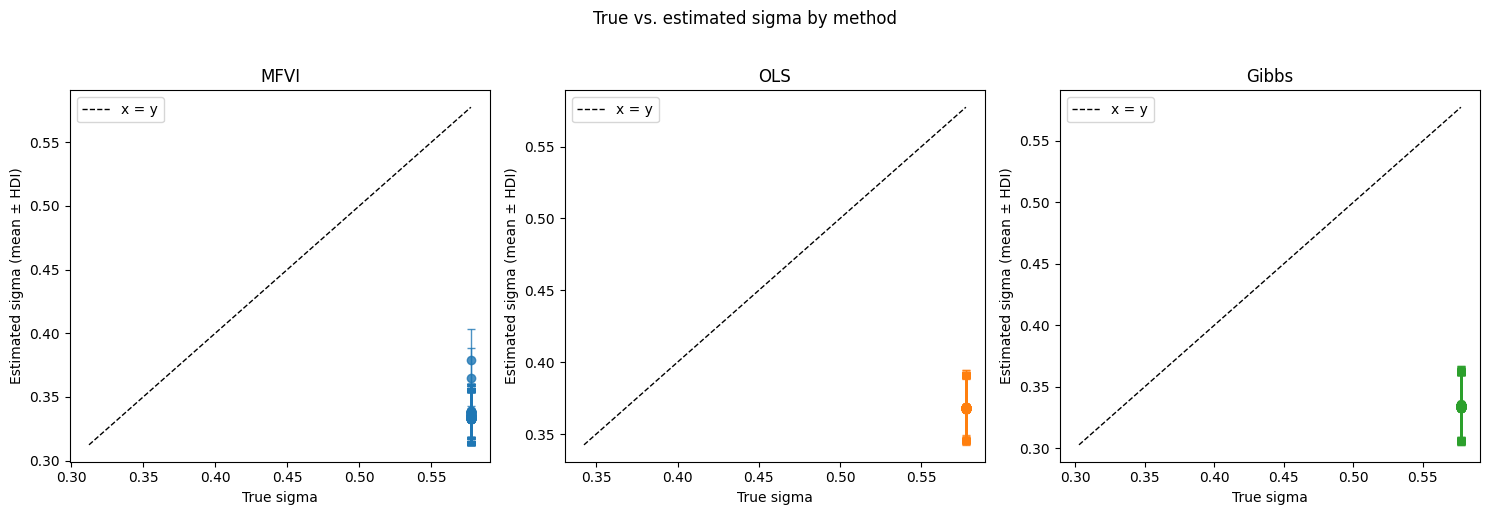

In [127]:
import matplotlib.pyplot as plt
import numpy as np

sigmas = {
    method: [
        pd.read_csv(f"{folder}/{seed}/{method}_{seed}_sigma.csv", index_col=0)
        for seed in subfolders
    ]
    for method in methods
}




methods_order = ["mfvi", "ols", "gibbs"]
labels = {"mfvi": "MFVI", "ols": "OLS", "gibbs": "Gibbs"}
colors = {"mfvi": "tab:blue", "ols": "tab:orange", "gibbs": "tab:green"}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, method in zip(axes, methods_order):
    dfs = sigmas[method]
    true_vals = np.array([df.loc["sigma", "true_value"] for df in dfs])
    est_means = np.array([df.loc["sigma", "mean"] for df in dfs])
    hdi_low = np.array([df.loc["sigma", "hdi_low"] for df in dfs])
    hdi_high = np.array([df.loc["sigma", "hdi_high"] for df in dfs])

    # Asymmetric error bars from HDI bounds
    yerr_lower = est_means - hdi_low
    yerr_upper = hdi_high - est_means

    ax.errorbar(
        true_vals,
        est_means,
        yerr=[yerr_lower, yerr_upper],
        fmt="o",
        color=colors[method],
        ecolor=colors[method],
        elinewidth=1,
        capsize=3,
        alpha=0.8,
    )

    # Dashed x = y reference line, scoped to this panel's own data range
    lims = [min(true_vals.min(), hdi_low.min()), max(true_vals.max(), hdi_high.max())]
    ax.plot(lims, lims, linestyle="--", color="black", linewidth=1, label="x = y")

    ax.set_title(labels[method])
    ax.set_xlabel("True sigma")
    ax.set_ylabel("Estimated sigma (mean ± HDI)")
    ax.legend(loc="best")

fig.suptitle("True vs. estimated sigma by method", y=1.02)
plt.tight_layout()
plt.show()

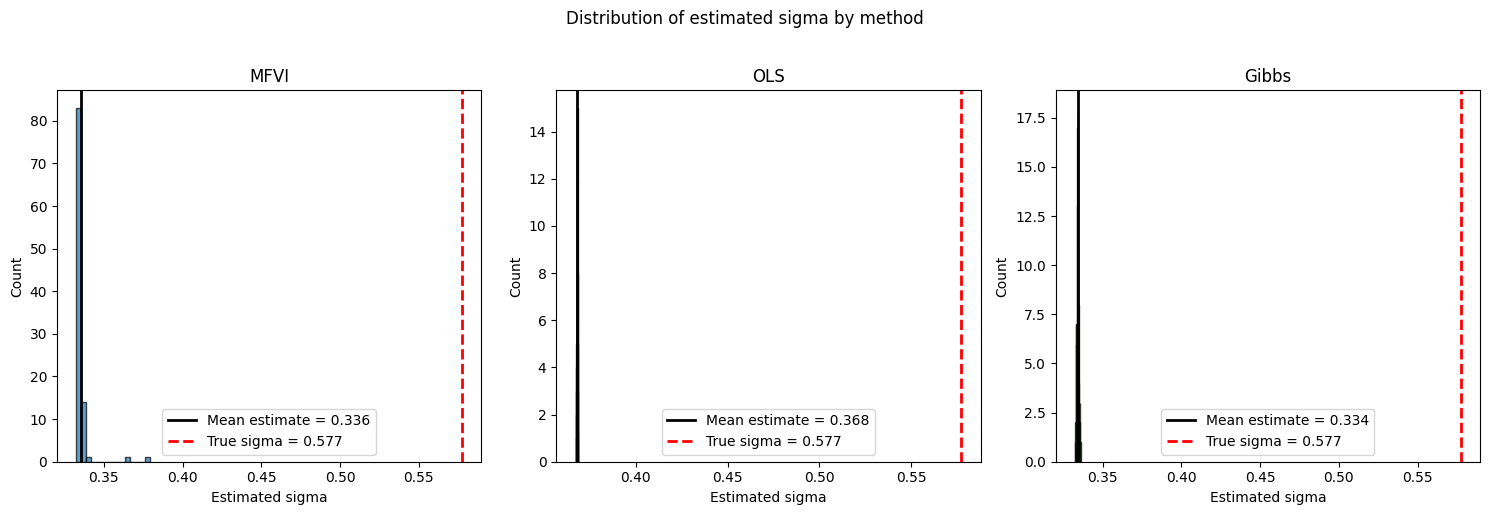

In [128]:
import matplotlib.pyplot as plt
import numpy as np

sigmas = {
    method: [
        pd.read_csv(f"{folder}/{seed}/{method}_{seed}_sigma.csv", index_col=0)
        for seed in subfolders
    ]
    for method in methods
}

methods_order = ["mfvi", "ols", "gibbs"]
labels = {"mfvi": "MFVI", "ols": "OLS", "gibbs": "Gibbs"}
colors = {"mfvi": "tab:blue", "ols": "tab:orange", "gibbs": "tab:green"}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, method in zip(axes, methods_order):
    dfs = sigmas[method]
    est_means = np.array([df.loc["sigma", "mean"] for df in dfs])
    # true_value is constant across seeds, just take it from the first one
    true_val = dfs[0].loc["sigma", "true_value"]

    ax.hist(
        est_means,
        bins=15,
        color=colors[method],
        alpha=0.7,
        edgecolor="black",
    )

    # Mean of estimated sigmas across seeds
    ax.axvline(
        est_means.mean(),
        color="black",
        linestyle="-",
        linewidth=2,
        label=f"Mean estimate = {est_means.mean():.3f}",
    )

    # True sigma value (theoretical)
    ax.axvline(
        true_val,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"True sigma = {true_val:.3f}",
    )

    ax.set_title(labels[method])
    ax.set_xlabel("Estimated sigma")
    ax.set_ylabel("Count")
    ax.legend(loc="best")

fig.suptitle("Distribution of estimated sigma by method", y=1.02)
plt.tight_layout()
plt.show()

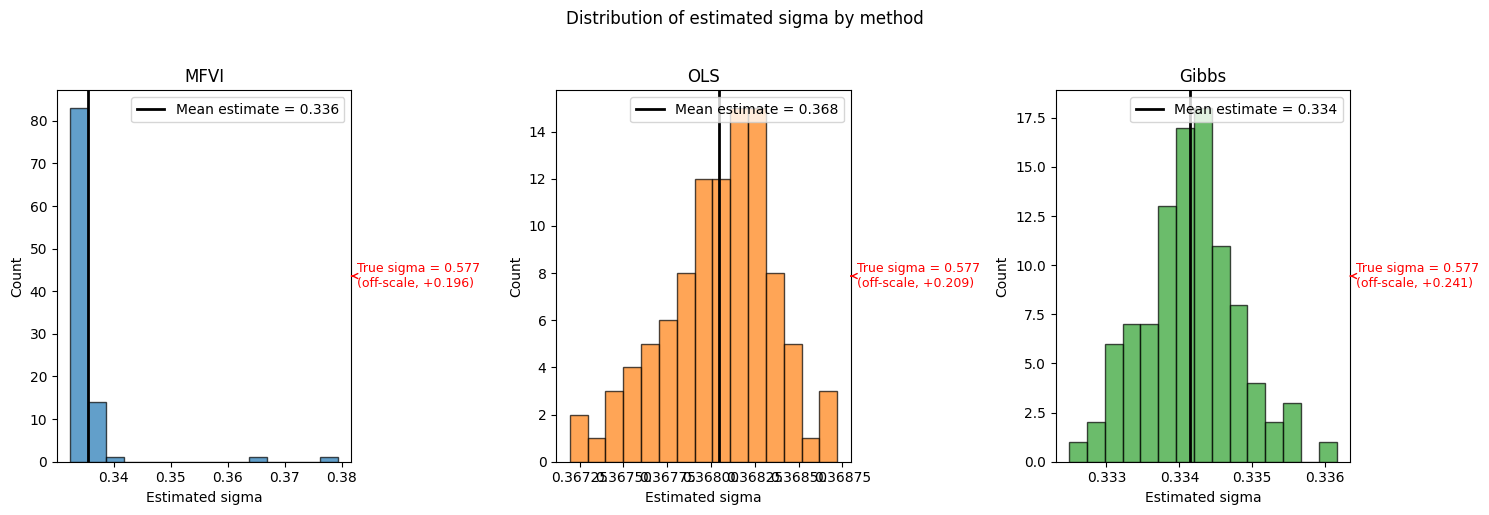

In [134]:
import matplotlib.pyplot as plt
import numpy as np

sigmas = {
    method: [
        pd.read_csv(f"{folder}/{seed}/{method}_{seed}_sigma.csv", index_col=0)
        for seed in subfolders
    ]
    for method in methods
}

methods_order = ["mfvi", "ols", "gibbs"]
labels = {"mfvi": "MFVI", "ols": "OLS", "gibbs": "Gibbs"}
colors = {"mfvi": "tab:blue", "ols": "tab:orange", "gibbs": "tab:green"}

true_val = sigmas[methods_order[0]][0].loc["sigma", "true_value"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, method in zip(axes, methods_order):
    dfs = sigmas[method]
    est_means = np.array([df.loc["sigma", "mean"] for df in dfs])

    ax.hist(
        est_means,
        bins=15,
        color=colors[method],
        alpha=0.7,
        edgecolor="black",
    )

    # Mean of estimated sigmas across seeds
    ax.axvline(
        est_means.mean(),
        color="black",
        linestyle="-",
        linewidth=2,
        label=f"Mean estimate = {est_means.mean():.3f}",
    )

    # Let this panel keep its own tight x-range so the distribution is visible
    ax.relim()
    xmin, xmax = ax.get_xlim()

    # Indicate the true sigma with an arrow at the right edge instead of
    # stretching the axis to include it (which would flatten the histogram)
    ax.annotate(
        f"True sigma = {true_val:.3f}\n(off-scale, +{true_val - xmax:.3f})",
        xy=(1.0, 0.5),
        xycoords="axes fraction",
        xytext=(1.02, 0.5),
        textcoords="axes fraction",
        va="center",
        ha="left",
        fontsize=9,
        color="red",
        arrowprops=dict(arrowstyle="->", color="red"),
    )

    ax.set_title(labels[method])
    ax.set_xlabel("Estimated sigma")
    ax.set_ylabel("Count")
    ax.legend(loc="upper right")

fig.suptitle("Distribution of estimated sigma by method", y=1.02)
plt.tight_layout()
plt.show()

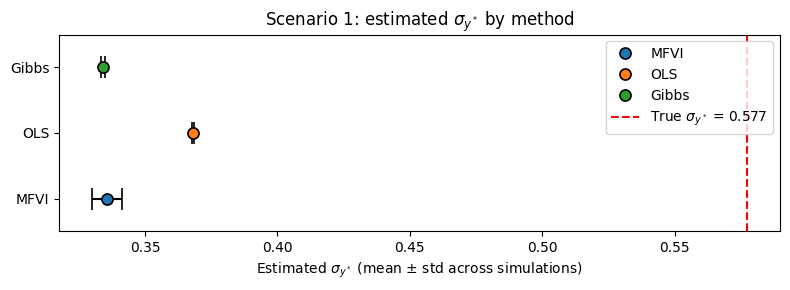

In [152]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from matplotlib.lines import Line2D

sigmas = {
    method: [
        pd.read_csv(f"{folder}/{seed}/{method}_{seed}_sigma.csv", index_col=0)
        for seed in subfolders
    ]
    for method in methods
}

methods_order = ["mfvi", "ols", "gibbs"]
labels = {"mfvi": "MFVI", "ols": "OLS", "gibbs": "Gibbs"}
colors = {"mfvi": "tab:blue", "ols": "tab:orange", "gibbs": "tab:green"}

true_val = sigmas[methods_order[0]][0].loc["sigma", "true_value"]

fig, ax = plt.subplots(figsize=(8, 3))

y_positions = np.arange(len(methods_order))

for y, method in zip(y_positions, methods_order):
    dfs = sigmas[method]
    est_means = np.array([df.loc["sigma", "mean"] for df in dfs])
    n = len(est_means)

    mean = est_means.mean()
    # Standard deviation across simulations instead of CI of the mean
    std = est_means.std(ddof=1)

    ax.errorbar(
        mean, y,
        xerr=std,
        fmt="o",
        markersize=8,
        markerfacecolor=colors[method],
        markeredgecolor="black",
        markeredgewidth=1.2,
        ecolor="black",
        elinewidth=1.5,
        capsize=8,
        capthick=1.5,
    )

# Reference line for the true sigma value
ax.axvline(
    true_val,
    color="red",
    linestyle="--",
    linewidth=1.5,
)

ax.set_yticks(y_positions)
ax.set_yticklabels([labels[m] for m in methods_order])
ax.set_ylim(-0.5, len(methods_order) - 0.5)
ax.set_xlabel(r"Estimated $\sigma_{{y^*}}$ (mean ± std across simulations)")
ax.set_title(rf"Scenario {scenario_nr}: estimated $\sigma_{{y^*}}$ by method")

# Build custom legend handles: one colored dot per method, plus the true sigma line
method_handles = [
    Line2D(
        [0], [0],
        marker="o", linestyle="",
        markerfacecolor=colors[m], markeredgecolor="black", markeredgewidth=1.2,
        markersize=8, label=labels[m],
    )
    for m in methods_order
]
true_handle = Line2D(
    [0], [0], color="red", linestyle="--", linewidth=1.5,
    label=rf"True $\sigma_{{y^*}}$ = {true_val:.3f}",
)

ax.legend(handles=method_handles + [true_handle], loc="upper right")

plt.tight_layout()
plt.show()